# Modeling

## Imports and functions

In [259]:
SEED = 42

import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Classifiers
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

In [260]:
def engineer_features_v1(df):
    df = df.copy()
    
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
    
    df['Deck'] = df['Cabin'].apply(lambda x: x[0] if pd.notnull(x) else 'U')
    
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

    df['Fare_Per_Person'] = df['Fare'] / df['FamilySize']
    
    df["HasCabin"] = df["Cabin"].notna().astype(int)
    
    cols_to_drop = ['Ticket', 'Cabin']

    return df.drop(columns=[c for c in cols_to_drop if c in df.columns])

In [261]:
class TitanicAgeImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.master_medians = None
        self.general_medians = None
        self.global_median = None

    def fit(self, X, y=None):
        X = X.copy()
        X['Title'] = X['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
        
        masters = X[X['Title'] == 'Master']
        self.master_medians = masters.groupby('Pclass')['Age'].median()
        self.general_medians = X.groupby(['Pclass', 'Sex'])['Age'].median()
        self.global_median = X['Age'].median()
        
        return self

    def transform(self, X):
        X = X.copy()
        X['Title'] = X['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
        
        mask_master = (X['Age'].isnull()) & (X['Title'] == 'Master')
        X.loc[mask_master, 'Age'] = X.loc[mask_master, 'Pclass'].map(self.master_medians)
        
        mask_remaining = X['Age'].isnull()
        fill_values = X[mask_remaining].apply(
            lambda row: self.general_medians.get((row['Pclass'], row['Sex']), self.global_median), 
            axis=1
        )
        X.loc[mask_remaining, 'Age'] = fill_values
        
        X['Age'] = X['Age'].fillna(self.global_median)
        
        return X.drop(columns=['Title', 'Name'])

## Features and Target

In [262]:
train_raw = pd.read_csv('../data/train.csv')

In [263]:
X = engineer_features_v1(train_raw)
y = X['Survived']
X = X.drop(columns=['Survived','PassengerId'])

In [264]:
X

,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Deck,Fare_Per_Person,HasCabin
0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,7.2500,S,2,0,U,3.62500,0
1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,71.2833,C,2,0,C,35.64165,1
2,3,"Heikkinen, Miss. Laina",1,26.0,0,0,7.9250,S,1,1,U,7.92500,0
3,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,53.1000,S,2,0,C,26.55000,1
4,3,"Allen, Mr. William Henry",0,35.0,0,0,8.0500,S,1,1,U,8.05000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,2,"Montvila, Rev. Juozas",0,27.0,0,0,13.0000,S,1,1,U,13.00000,0
887,1,"Graham, Miss. Margaret Edith",1,19.0,0,0,30.0000,S,1,1,B,30.00000,1
888,3,"Johnston, Miss. Catherine Helen ""Carrie""",1,NaN,1,2,23.4500,S,4,0,U,5.86250,0
889,1,"Behr, Mr. Karl Howell",0,26.0,0,0,30.0000,C,1,1,C,30.00000,1


## Train / Validation Split

I will implement the `stratify` parameter during the data split to ensure that the train and validation sets maintain an equal proportion of the target classes.\
This approach prevents sampling bias and ensures that the model is evaluated on a representative distribution of the data.

In [265]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)

## One-hot encoding

In [266]:
X_train = pd.get_dummies(X_train, columns=['Embarked', 'Deck'], drop_first=True)
X_val = pd.get_dummies(X_val, columns=['Embarked', 'Deck'], drop_first=True)

X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)

## Models

### Random Forest

#### Model

In [267]:
rf_pipeline = Pipeline(steps=[
    ('age_imputer', TitanicAgeImputer()),
    ('safety_imputer', SimpleImputer(strategy='median')),
    #('scaler', StandardScaler()),
    ('model', RandomForestClassifier(
        n_estimators=150,
        max_depth=5,
        min_samples_leaf=4,
        random_state=SEED
    ))
])

In [268]:
skf_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_pred_cv_rf = cross_val_predict(rf_pipeline, X_train, y_train, cv=skf_rf)
print(f"Accuracy: {accuracy_score(y_train, y_pred_cv_rf):.4f}\n")

Accuracy: 0.8160



#### Classification Report

In [269]:
print(classification_report(y_train, y_pred_cv_rf))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86       439
           1       0.80      0.69      0.74       273

    accuracy                           0.82       712
   macro avg       0.81      0.79      0.80       712
weighted avg       0.81      0.82      0.81       712



#### Confusion Matrix

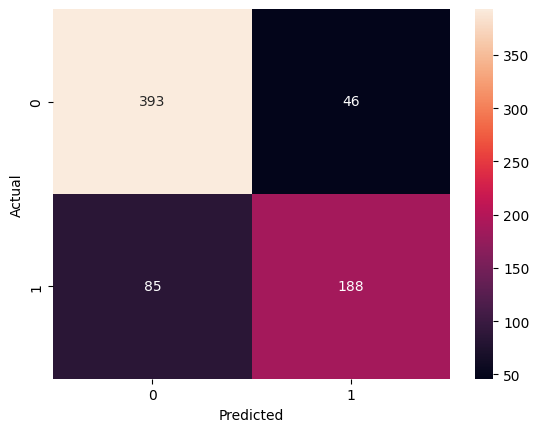

In [270]:
cm_rf = confusion_matrix(y_train, y_pred_cv_rf)

sns.heatmap(cm_rf, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Cross Validation

In [271]:
cv_scores_rf = cross_val_score(rf_pipeline, X_train, y_train, cv=skf_rf, scoring='accuracy')

print(f"Folds Scores: {np.round(cv_scores_rf, 4)}")
print(f"Average Accuracy: {cv_scores_rf.mean():.4f}")
print(f"Standard Deviation: {cv_scores_rf.std():.4f}")

Folds Scores: [0.8462 0.7832 0.831  0.8099 0.8099]
Average Accuracy: 0.8160
Standard Deviation: 0.0214


#### Hyperparameter Tuning

In [272]:
param_grid_rf = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [4, 5, 6, 7],
    'model__min_samples_leaf': [3, 4, 5],
}

grid_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=skf_rf,
    verbose=2, 
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)

print(f"Best parameters found: {grid_rf.best_params_}")
print(f"Best cross-validation score: {grid_rf.best_score_}")

best_rf_pipeline = grid_rf.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters found: {'model__max_depth': 6, 'model__min_samples_leaf': 4, 'model__n_estimators': 200}
Best cross-validation score: 0.8286614793657048


#### Feature importance

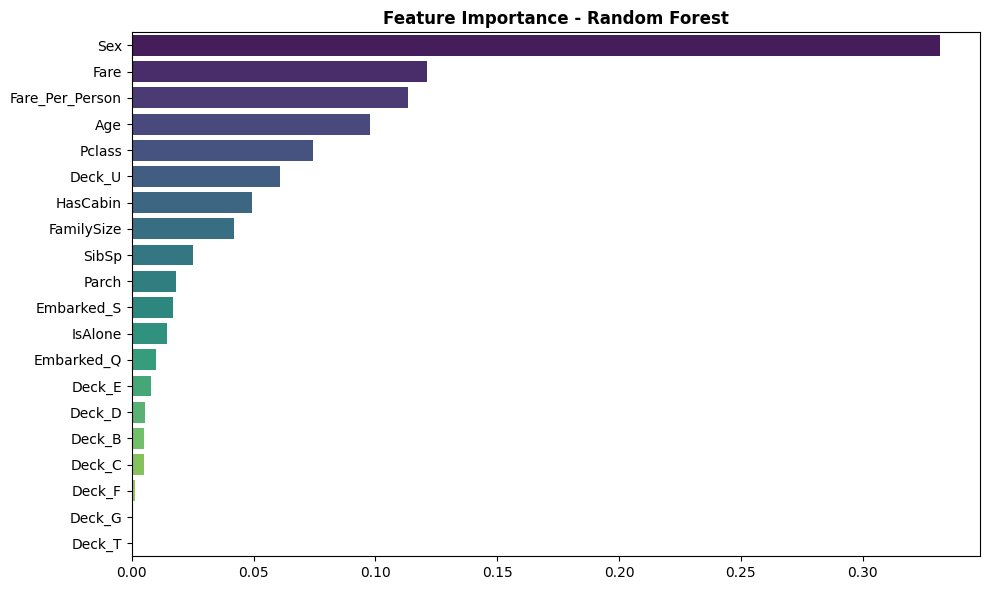

In [273]:
best_rf_pipeline.fit(X_train, y_train)
modelo_rf = best_rf_pipeline.named_steps['model']

importances_rf = modelo_rf.feature_importances_
features = X_train.drop(columns=['Name'], errors='ignore').columns

df_importances_rf = pd.DataFrame({
    'Feature': features,
    'Importances': importances_rf
}).sort_values(by='Importances', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importances_rf, 
    x='Importances', 
    y='Feature', 
    hue='Feature',
    palette='viridis', 
    legend=False
)
plt.title('Feature Importance - Random Forest', fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### Final Model training

Accuracy: 0.7654

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       110
           1       0.71      0.65      0.68        69

    accuracy                           0.77       179
   macro avg       0.75      0.74      0.75       179
weighted avg       0.76      0.77      0.76       179

--- CV score ---
Folds Scores: [0.8392 0.8112 0.8451 0.8169 0.831 ]
Average Accuracy: 0.8287
Standard Deviation: 0.0129

--- Confusion Matrix ---


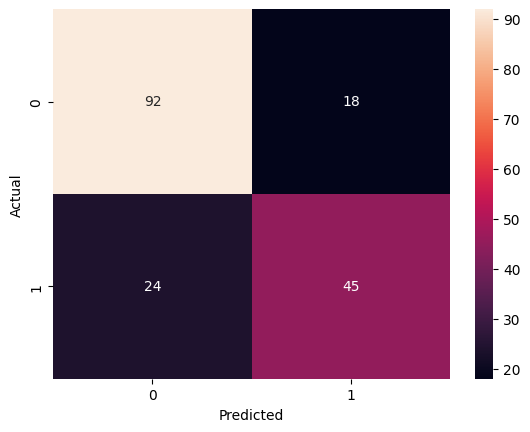

In [274]:
best_rf_pipeline.fit(X_train, y_train)
y_pred_val_rf = best_rf_pipeline.predict(X_val)

print(f"Accuracy: {accuracy_score(y_val, y_pred_val_rf):.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_val, y_pred_val_rf))

print("--- CV score ---")
cv_scores_rf = cross_val_score(best_rf_pipeline, X_train, y_train, cv=skf_rf, scoring='accuracy')
print(f"Folds Scores: {np.round(cv_scores_rf, 4)}")
print(f"Average Accuracy: {cv_scores_rf.mean():.4f}")
print(f"Standard Deviation: {cv_scores_rf.std():.4f}")

print("\n--- Confusion Matrix ---")
cm_rf = confusion_matrix(y_val, y_pred_val_rf)

sns.heatmap(cm_rf, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Gradient Boosting

#### Model

In [275]:
gb_pipeline = Pipeline(steps=[
    ('age_imputer', TitanicAgeImputer()),
    ('safety_imputer', SimpleImputer(strategy='median')),
    #('scaler', StandardScaler()),
    ('model', GradientBoostingClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        random_state=SEED
    ))
])

In [276]:
skf_gb = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_pred_cv_gb = cross_val_predict(gb_pipeline, X_train, y_train, cv=skf_gb)
print(f"Accuracy: {accuracy_score(y_train, y_pred_cv_gb):.4f}\n")

Accuracy: 0.8399



#### Classification Report

In [277]:
print(classification_report(y_train, y_pred_cv_gb))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87       439
           1       0.82      0.75      0.78       273

    accuracy                           0.84       712
   macro avg       0.83      0.82      0.83       712
weighted avg       0.84      0.84      0.84       712



#### Confusion Matrix

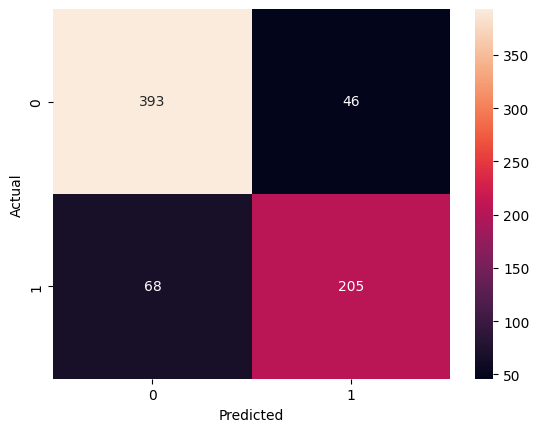

In [278]:
cm_gb = confusion_matrix(y_train, y_pred_cv_gb)

sns.heatmap(cm_gb, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Cross Validation

In [279]:
cv_scores_gb = cross_val_score(gb_pipeline, X_train, y_train, cv=skf_gb, scoring='accuracy')

print(f"Folds Scores: {np.round(cv_scores_gb, 4)}")
print(f"Average Accuracy: {cv_scores_gb.mean():.4f}")
print(f"Standard Deviation:     {cv_scores_gb.std():.4f}")

Folds Scores: [0.8671 0.7762 0.8521 0.8451 0.8592]
Average Accuracy: 0.8399
Standard Deviation:     0.0327


#### Hyperparameter Tuning

In [280]:
param_grid_gb = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 4, 5],
    'model__subsample': [0.8, 0.9, 1.0]
}

grid_gb = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid_gb,
    cv=skf_gb,
    verbose=2, 
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print(f"Best parameters found: {grid_gb.best_params_}")
print(f"Best cross-validation score: {grid_gb.best_score_}")

best_gb_pipeline = grid_gb.best_estimator_

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best parameters found: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best cross-validation score: 0.8399389343051314


#### Feature importance

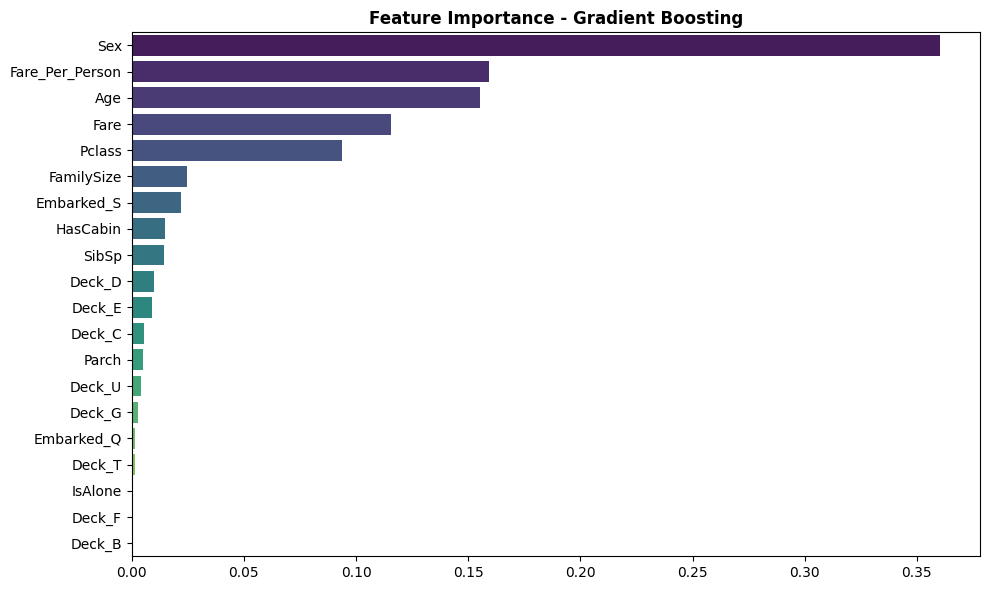

In [281]:
best_gb_pipeline.fit(X_train, y_train)
modelo_gb = best_gb_pipeline.named_steps['model']

importances_gb = modelo_gb.feature_importances_
features = X_train.drop(columns=['Name'], errors='ignore').columns

df_importances_gb = pd.DataFrame({
    'Feature': features,
    'Importances': importances_gb
}).sort_values(by='Importances', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importances_gb, 
    x='Importances', 
    y='Feature', 
    hue='Feature',
    palette='viridis', 
    legend=False
)
plt.title('Feature Importance - Gradient Boosting', fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### Final Model training

Accuracy: 0.7709

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       110
           1       0.73      0.65      0.69        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.77      0.77      0.77       179

--- CV score ---
Folds Scores: [0.8671 0.7762 0.8521 0.8451 0.8592]
Average Accuracy: 0.8399
Standard Deviation:     0.0327

--- Confusion Matrix ---


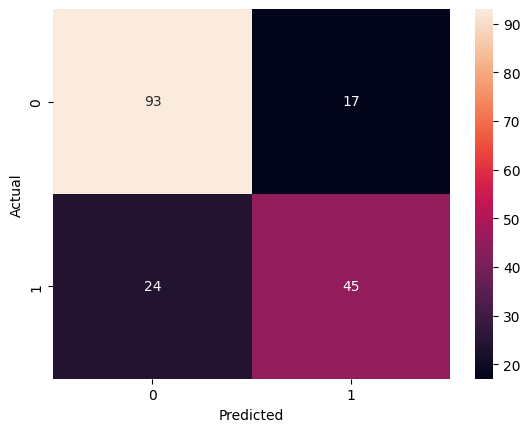

In [282]:
best_gb_pipeline.fit(X_train, y_train)
y_pred_val_gb = best_gb_pipeline.predict(X_val)

print(f"Accuracy: {accuracy_score(y_val, y_pred_val_gb):.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_val, y_pred_val_gb))

print("--- CV score ---")
cv_scores = cross_val_score(best_gb_pipeline, X_train, y_train, cv=skf_gb, scoring='accuracy')
print(f"Folds Scores: {np.round(cv_scores, 4)}")
print(f"Average Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation:     {cv_scores.std():.4f}")

print("\n--- Confusion Matrix ---")
cm_gb = confusion_matrix(y_val, y_pred_val_gb)

sns.heatmap(cm_gb, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### AdaBoost

#### Model

In [283]:
ada_pipeline = Pipeline(steps=[
    ('age_imputer', TitanicAgeImputer()),
    ('safety_imputer', SimpleImputer(strategy='median')),
    #('scaler', StandardScaler()),
    ('model', AdaBoostClassifier(
        algorithm='SAMME',
        estimator=DecisionTreeClassifier(max_depth=1, random_state=SEED),
        n_estimators=300,
        learning_rate=0.1,
        random_state=SEED
    ))
])

In [284]:
skf_ada = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_pred_cv_ada = cross_val_predict(ada_pipeline, X_train, y_train, cv=skf_ada)
print(f"Accuracy: {accuracy_score(y_train, y_pred_cv_ada):.4f}\n")

Accuracy: 0.8118



#### Classification Report

In [285]:
print(classification_report(y_train, y_pred_cv_ada))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       439
           1       0.79      0.70      0.74       273

    accuracy                           0.81       712
   macro avg       0.81      0.79      0.80       712
weighted avg       0.81      0.81      0.81       712



#### Confusion Matrix

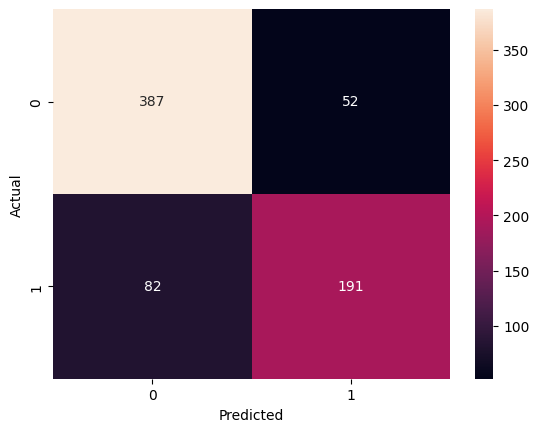

In [286]:
cm_ada = confusion_matrix(y_train, y_pred_cv_ada)

sns.heatmap(cm_ada, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Cross Validation

In [287]:
cv_scores_ada = cross_val_score(ada_pipeline, X_train, y_train, cv=skf_ada, scoring='accuracy')

print(f"Folds Scores: {np.round(cv_scores_ada, 4)}")
print(f"Average Accuracy: {cv_scores_ada.mean():.4f}")
print(f"Standard Deviation: {cv_scores_ada.std():.4f}")

Folds Scores: [0.8322 0.7692 0.831  0.8028 0.8239]
Average Accuracy: 0.8118
Standard Deviation: 0.0238


#### Hyperparameter Tuning

In [288]:
param_grid_ada = {
    'model__learning_rate': [0.01, 0.05, 0.1, 0.5],
    'model__n_estimators': [100, 200, 300],
    'model__estimator__max_depth': [1, 2]
}

grid_ada = GridSearchCV(
    estimator=ada_pipeline,
    param_grid=param_grid_ada,
    cv=skf_ada,
    verbose=2, 
    n_jobs=-1
)

grid_ada.fit(X_train, y_train)

print(f"Best parameters found: {grid_ada.best_params_}")
print(f"Best cross-validation score: {grid_ada.best_score_}")

best_ada_pipeline = grid_ada.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters found: {'model__estimator__max_depth': 2, 'model__learning_rate': 0.05, 'model__n_estimators': 200}
Best cross-validation score: 0.8259036737909977


#### Feature importance

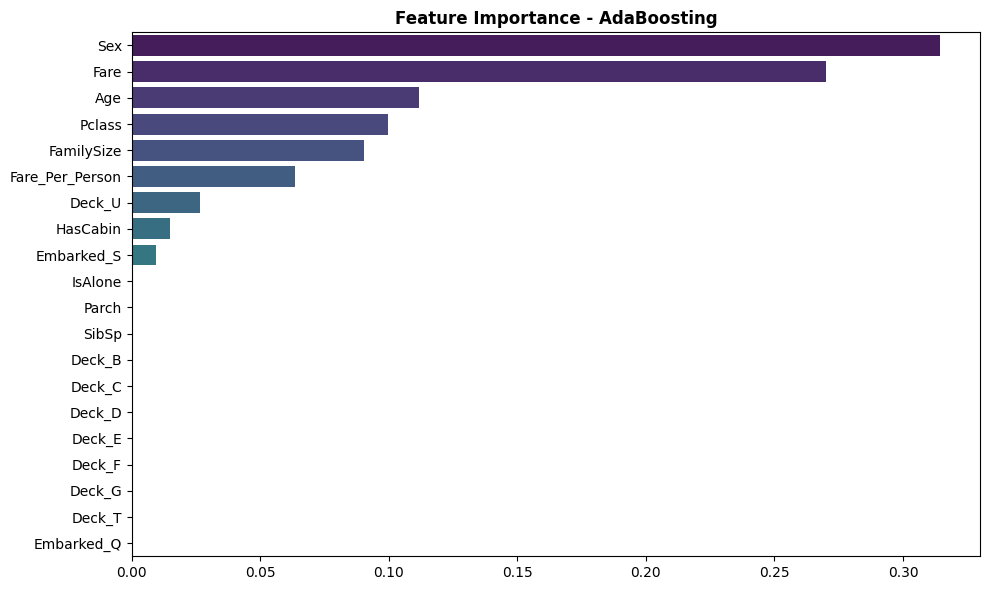

In [289]:
best_ada_pipeline.fit(X_train, y_train)
modelo_ada = best_ada_pipeline.named_steps['model']

importances_ada = modelo_ada.feature_importances_
features = X_train.drop(columns=['Name'], errors='ignore').columns

df_importances_ada = pd.DataFrame({
    'Feature': features,
    'Importances': importances_ada
}).sort_values(by='Importances', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importances_ada, 
    x='Importances', 
    y='Feature', 
    hue='Feature',
    palette='viridis', 
    legend=False
)
plt.title('Feature Importance - AdaBoosting', fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### Final Model training

Accuracy: 0.8045

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       110
           1       0.80      0.65      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.78       179
weighted avg       0.80      0.80      0.80       179

--- CV score ---
Folds Scores: [0.8322 0.7762 0.8732 0.8028 0.8451]
Average Accuracy: 0.8259
Standard Deviation: 0.0336

--- Confusion Matrix ---


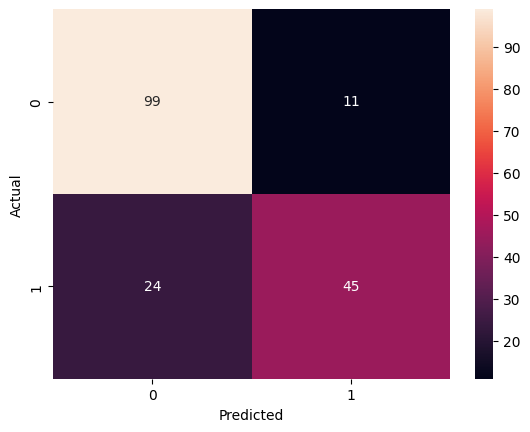

In [290]:
best_ada_pipeline.fit(X_train, y_train)
y_pred_val_ada = best_ada_pipeline.predict(X_val)

print(f"Accuracy: {accuracy_score(y_val, y_pred_val_ada):.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_val, y_pred_val_ada))

print("--- CV score ---")
cv_scores = cross_val_score(best_ada_pipeline, X_train, y_train, cv=skf_ada, scoring='accuracy')
print(f"Folds Scores: {np.round(cv_scores, 4)}")
print(f"Average Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

print("\n--- Confusion Matrix ---")
cm_ada = confusion_matrix(y_val, y_pred_val_ada)

sns.heatmap(cm_ada, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### XGBoost

#### Model

In [291]:
xgb_pipeline = Pipeline(steps=[
    ('age_imputer', TitanicAgeImputer()),
    ('safety_imputer', SimpleImputer(strategy='median')),
    #('scaler', StandardScaler()),
    ('model', XGBClassifier(
        #use_label_encoder=False,
        eval_metric='logloss',
        random_state=SEED
    ))
])

In [292]:
skf_xgb = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
y_pred_cv_xgb = cross_val_predict(xgb_pipeline, X_train, y_train, cv=skf_xgb)
print(f"Accuracy: {accuracy_score(y_train, y_pred_cv_xgb):.4f}\n")

Accuracy: 0.8076



#### Classification Report

In [293]:
print(classification_report(y_train, y_pred_cv_xgb))

              precision    recall  f1-score   support

           0       0.84      0.85      0.85       439
           1       0.76      0.73      0.74       273

    accuracy                           0.81       712
   macro avg       0.80      0.79      0.80       712
weighted avg       0.81      0.81      0.81       712



#### Confusion Matrix

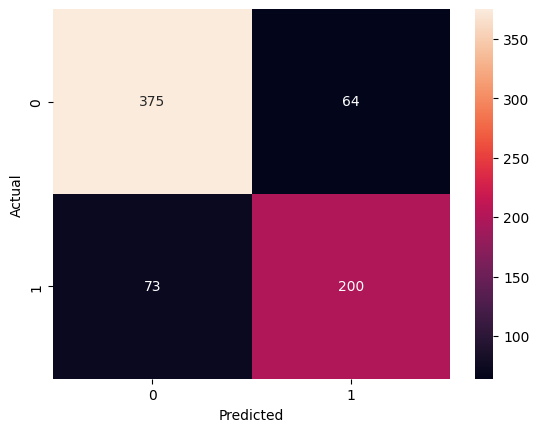

In [294]:
cm_xgb = confusion_matrix(y_train, y_pred_cv_xgb)

sns.heatmap(cm_xgb, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Cross Validation

In [295]:
cv_scores_xgb = cross_val_score(xgb_pipeline, X_train, y_train, cv=skf_xgb, scoring='accuracy')

print(f"Folds Scores: {np.round(cv_scores_xgb, 4)}")
print(f"Average Accuracy: {cv_scores_xgb.mean():.4f}")
print(f"Standard Deviation: {cv_scores_xgb.std():.4f}")

Folds Scores: [0.8322 0.7762 0.8028 0.7887 0.838 ]
Average Accuracy: 0.8076
Standard Deviation: 0.0241


#### Hyperparameter Tuning

In [296]:
param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__gamma': [0, 0.1, 0.5]
}

grid_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid_xgb,
    cv=skf_xgb,
    verbose=2,
    n_jobs=-1,
)

grid_xgb.fit(X_train, y_train)

print(f"Best parameters found: {grid_xgb.best_params_}")
print(f"Best cross-validation score: {grid_xgb.best_score_}")

best_xgb_pipeline = grid_xgb.best_estimator_

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best parameters found: {'model__colsample_bytree': 0.8, 'model__gamma': 0.5, 'model__learning_rate': 0.01, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best cross-validation score: 0.8455136412882892


#### Feature importance

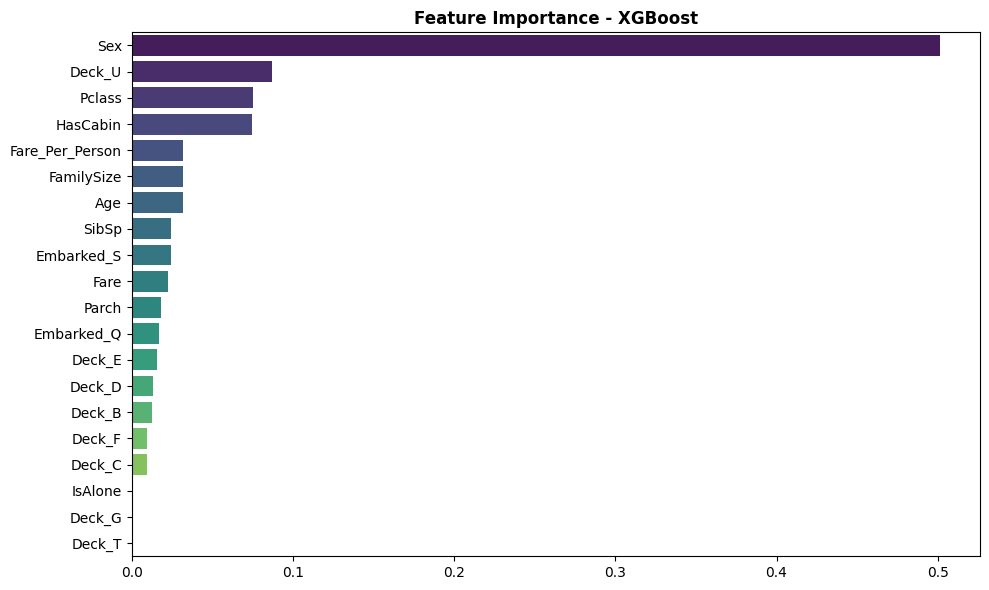

In [297]:
best_xgb_pipeline.fit(X_train, y_train)
modelo_xgb = best_xgb_pipeline.named_steps['model']

importances_xgb = modelo_xgb.feature_importances_
features = X_train.drop(columns=['Name'], errors='ignore').columns

df_importances_xgb = pd.DataFrame({
    'Feature': features,
    'Importances': importances_xgb
}).sort_values(by='Importances', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importances_xgb, 
    x='Importances', 
    y='Feature', 
    hue='Feature',
    palette='viridis', 
    legend=False
)
plt.title('Feature Importance - XGBoost', fontweight='bold')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### Final Model training

Accuracy: 0.7821

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.78      0.90      0.84       110
           1       0.79      0.59      0.68        69

    accuracy                           0.78       179
   macro avg       0.78      0.75      0.76       179
weighted avg       0.78      0.78      0.77       179

--- CV score ---
Folds Scores: [0.8531 0.8182 0.8732 0.8451 0.8239]
Average Accuracy: 0.8427
Standard Deviation: 0.0200

--- Confusion Matrix ---


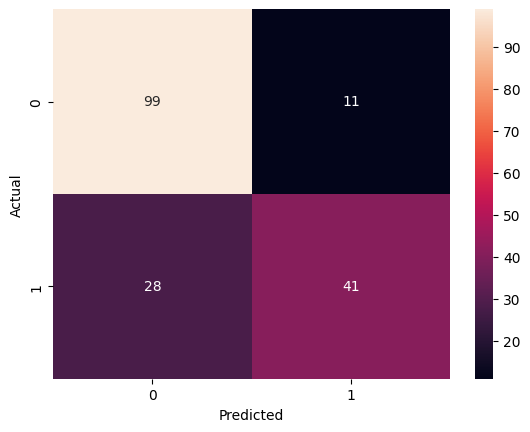

In [298]:
best_xgb_pipeline.fit(X_train, y_train)
y_pred_val_xgb = best_xgb_pipeline.predict(X_val)

print(f"Accuracy: {accuracy_score(y_val, y_pred_val_xgb):.4f}\n")

print("--- Classification Report ---")
print(classification_report(y_val, y_pred_val_xgb))

print("--- CV score ---")
cv_scores = cross_val_score(best_xgb_pipeline, X_train, y_train, cv=skf_xgb, scoring='accuracy')
print(f"Folds Scores: {np.round(cv_scores, 4)}")
print(f"Average Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

print("\n--- Confusion Matrix ---")
cm_xgb = confusion_matrix(y_val, y_pred_val_xgb)

sns.heatmap(cm_xgb, annot=True, fmt="d")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### VotingClassifier Submission

After optimizing and evaluating multiple tree-based algorithms (Random Forest, Gradient Boosting, AdaBoost, and XGBoost), I implemented a `VotingClassifier` to leverage the "wisdom of the crowds" through Soft Voting.

Initially, an ensemble incorporating all four models underperformed compared to the standalone AdaBoost and XGBoost.

To maximize the signal-to-noise ratio, I applied the principle of **Ensemble Pruning**. I decided to build the final model using exclusively the top two performing algorithms: **AdaBoost** and **XGBoost**. 

This strategic combination successfully leveraged their distinct mathematical architectures, mitigating individual biases without diluting their high-confidence predictions, which ultimately yielded the best generalization score on the Kaggle Leaderboard.

In [ ]:
train_raw = pd.read_csv('../data/train.csv')
test_raw = pd.read_csv('../data/test.csv')

test_passenger_ids = test_raw['PassengerId']

y_train = train_raw['Survived']
X_train = train_raw.drop(columns=['Survived','PassengerId'])
X_test = test_raw.copy()

X_train = engineer_features_v1(X_train)
X_test = engineer_features_v1(X_test)

X_train = pd.get_dummies(X_train, columns=['Embarked', 'Deck'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Embarked', 'Deck'], drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

voting_ensemble = VotingClassifier(
    estimators=[
        ('AdaBoost', best_ada_pipeline),
        ('XGBoost', best_xgb_pipeline)
    ],
    voting='soft',
    n_jobs=-1
)

print("Fitting final model with all train dataset...")
voting_ensemble.fit(X_train, y_train)

print("Predicting to test.csv...")
predictions = voting_ensemble.predict(X_test)

submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Survived': predictions
})

#submission_file = '../data/submission.csv'
#submission.to_csv(submission_file, index=False)

#print(f"Done! '{submission_file}'")

Fitting final model with all train dataset...
Predicting to test.csv...
Done! '../data/submission.csv'


# Final Reporting

| Model | Accuracy | Mean CV | Kaggle score
|---|---|---|---|
RandomForest | 76% | 82% | 0.75598
GradientBoost | 77% | 83% | 0.76794
AdaBoost | 80% | 82% | 0.77751
XGBoost | 78% | 84% | 0.77272
VotingClassifier |-|-|0.78708

## Submission pipeline

In [300]:
def submission():
    train_raw = pd.read_csv('../data/train.csv')
    test_raw = pd.read_csv('../data/test.csv')

    test_passenger_ids = test_raw['PassengerId']

    y_train = train_raw['Survived']
    X_train = train_raw.drop(columns=['Survived','PassengerId'])
    X_test = test_raw.copy()

    X_train = engineer_features_v1(X_train)
    X_test = engineer_features_v1(X_test)

    X_train = pd.get_dummies(X_train, columns=['Embarked'], drop_first=True)
    X_test = pd.get_dummies(X_test, columns=['Embarked'], drop_first=True)

    X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

    print("Fitting final model with all train dataset...")
    best_gb_pipeline.fit(X_train, y_train)

    print("Predicting to test.csv...")
    predictions = best_gb_pipeline.predict(X_test)

    submission = pd.DataFrame({
        'PassengerId': test_passenger_ids,
        'Survived': predictions
    })

    submission_file = '../data/submission.csv'
    submission.to_csv(submission_file, index=False)

    print(f"Done! '{submission_file}'")

#submission()